## 1. Загрузка данных

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df = pd.read_csv("/kaggle/input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv")

In [83]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [84]:
df.shape

(2111, 17)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

## 2. EDA (Exploratory Data Analysis)

In [86]:
df.describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [87]:
df.isnull().sum()

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

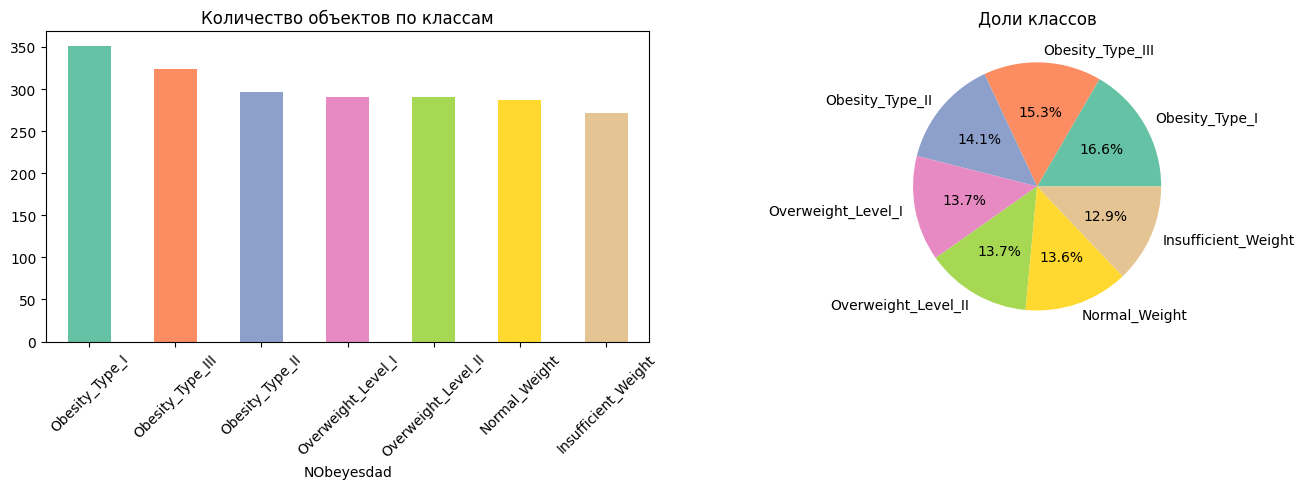

In [88]:
target_col = 'NObeyesdad'
fit, axes = plt.subplots(1, 2, figsize = (14, 5))

df[target_col].value_counts().plot.bar(ax = axes[0], color = sns.color_palette('Set2'))
axes[0].set_title("Количество объектов по классам")
axes[0].tick_params(axis = 'x', rotation = 45)


df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

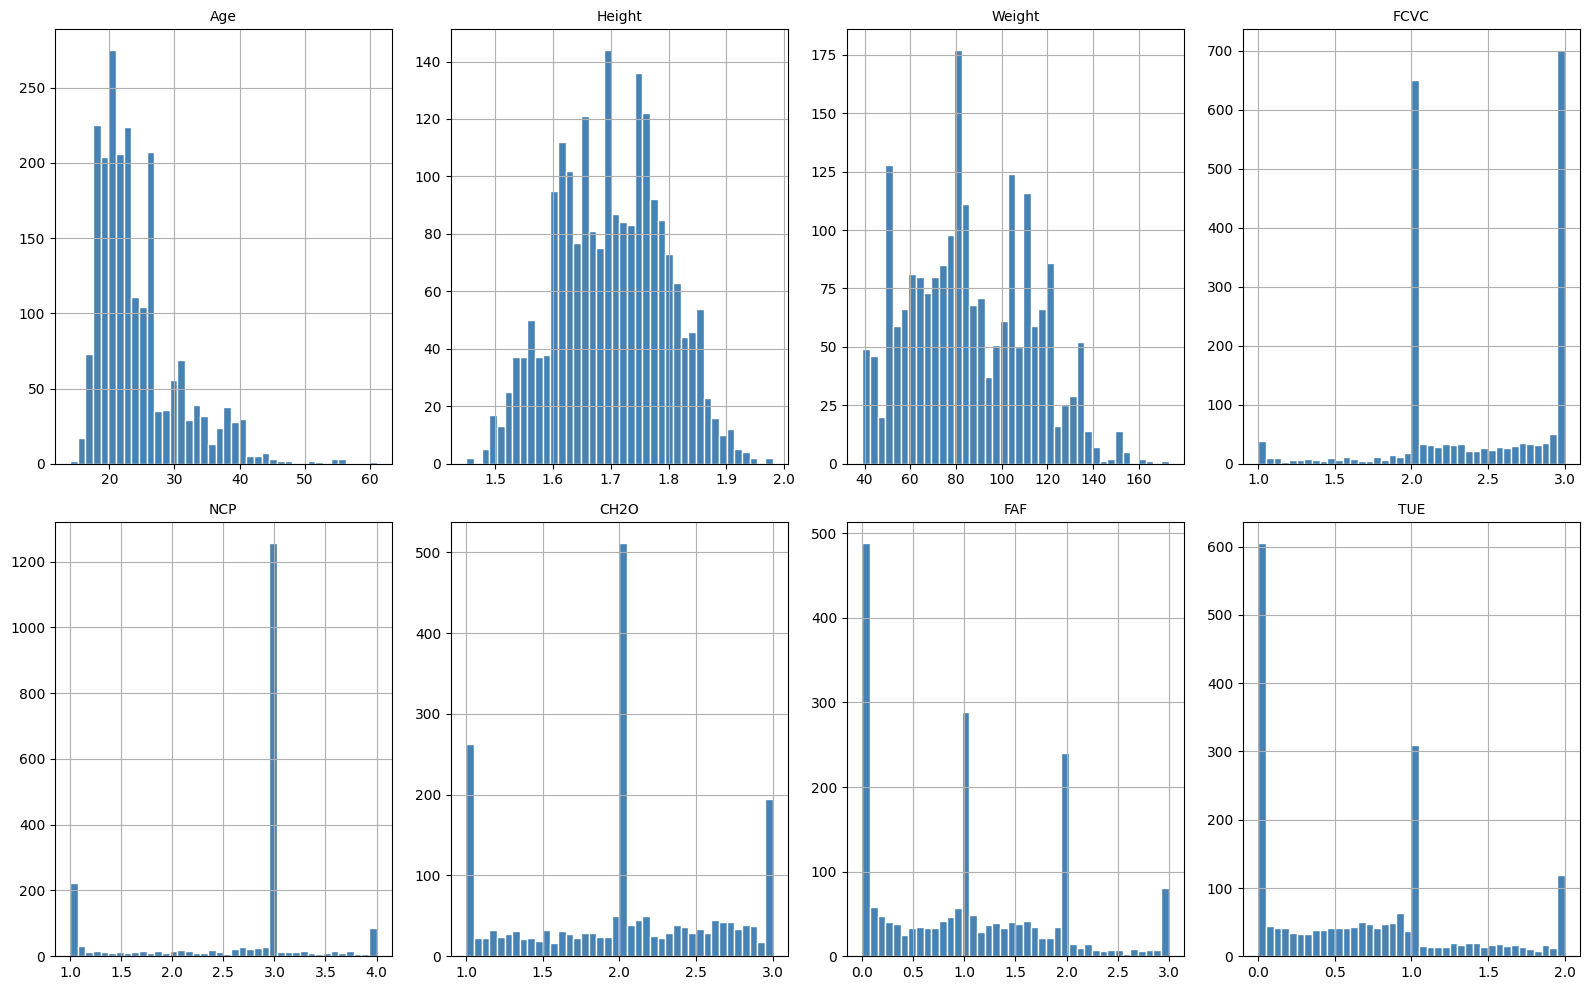

In [89]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

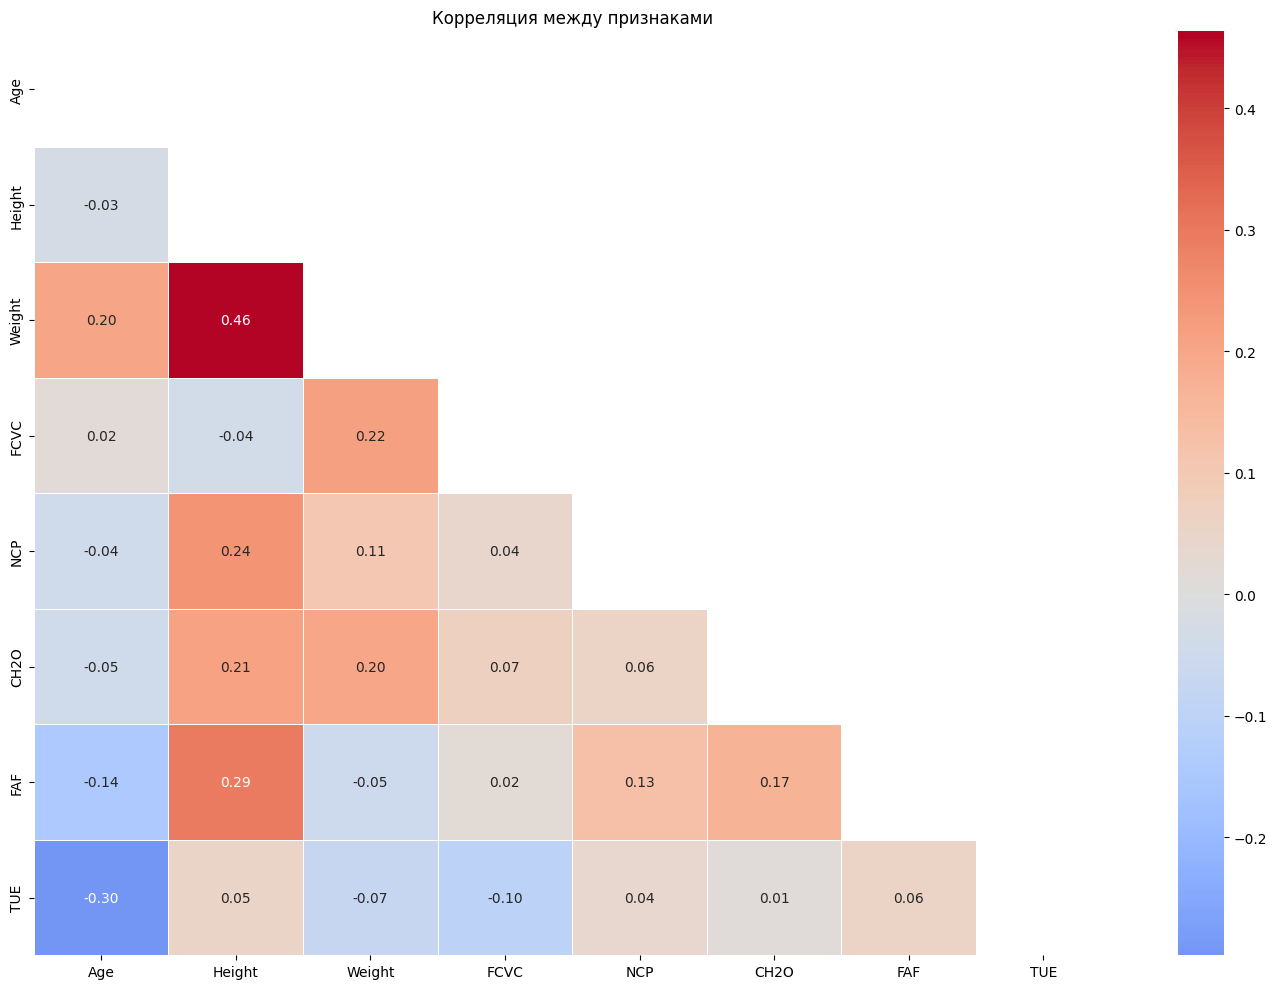

In [90]:
plt.figure(figsize = (14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr, mask = mask, annot = True, fmt = '.2f',cmap = 'coolwarm', center = 0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

/tmp/ipykernel_55/322124550.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
/tmp/ipykernel_55/322124550.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
/tmp/ipykernel_55/322124550.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
/tmp/ipykernel_55/322124550.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign th

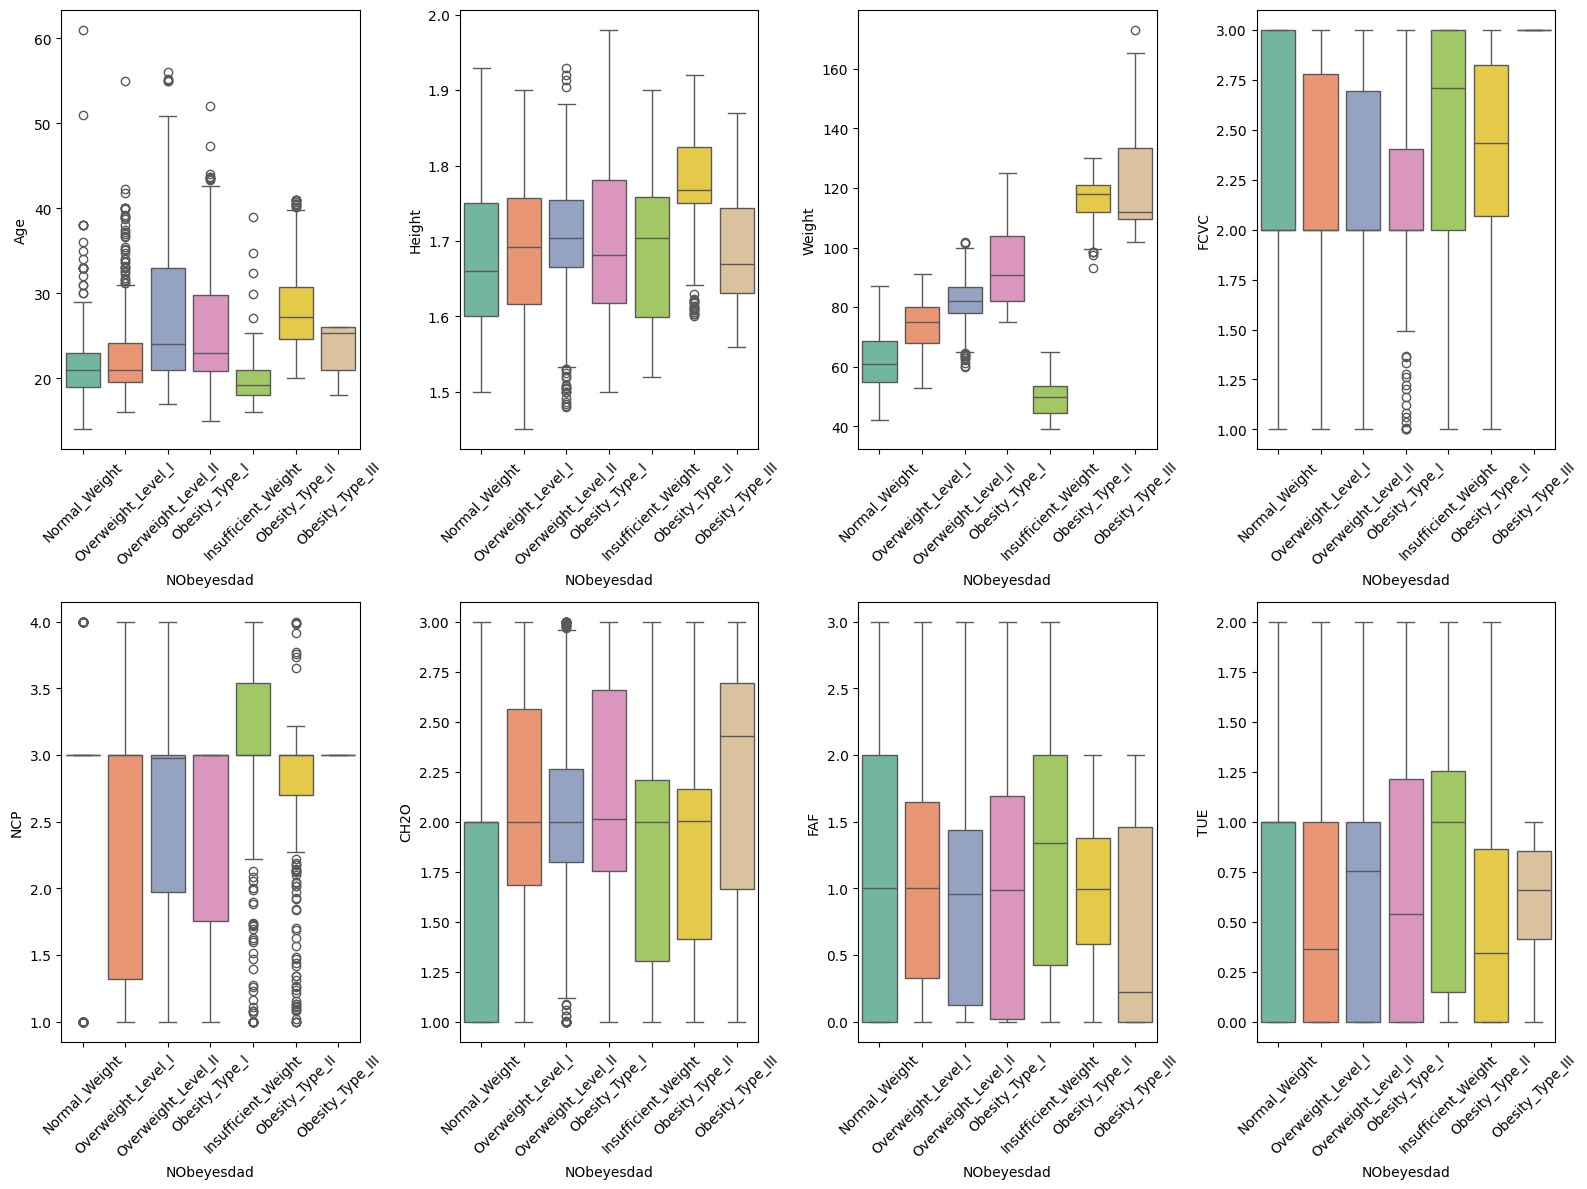

In [91]:
fig, axes = plt.subplots(2, 4, figsize = (16, 12))

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 4][idx % 4]
    sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

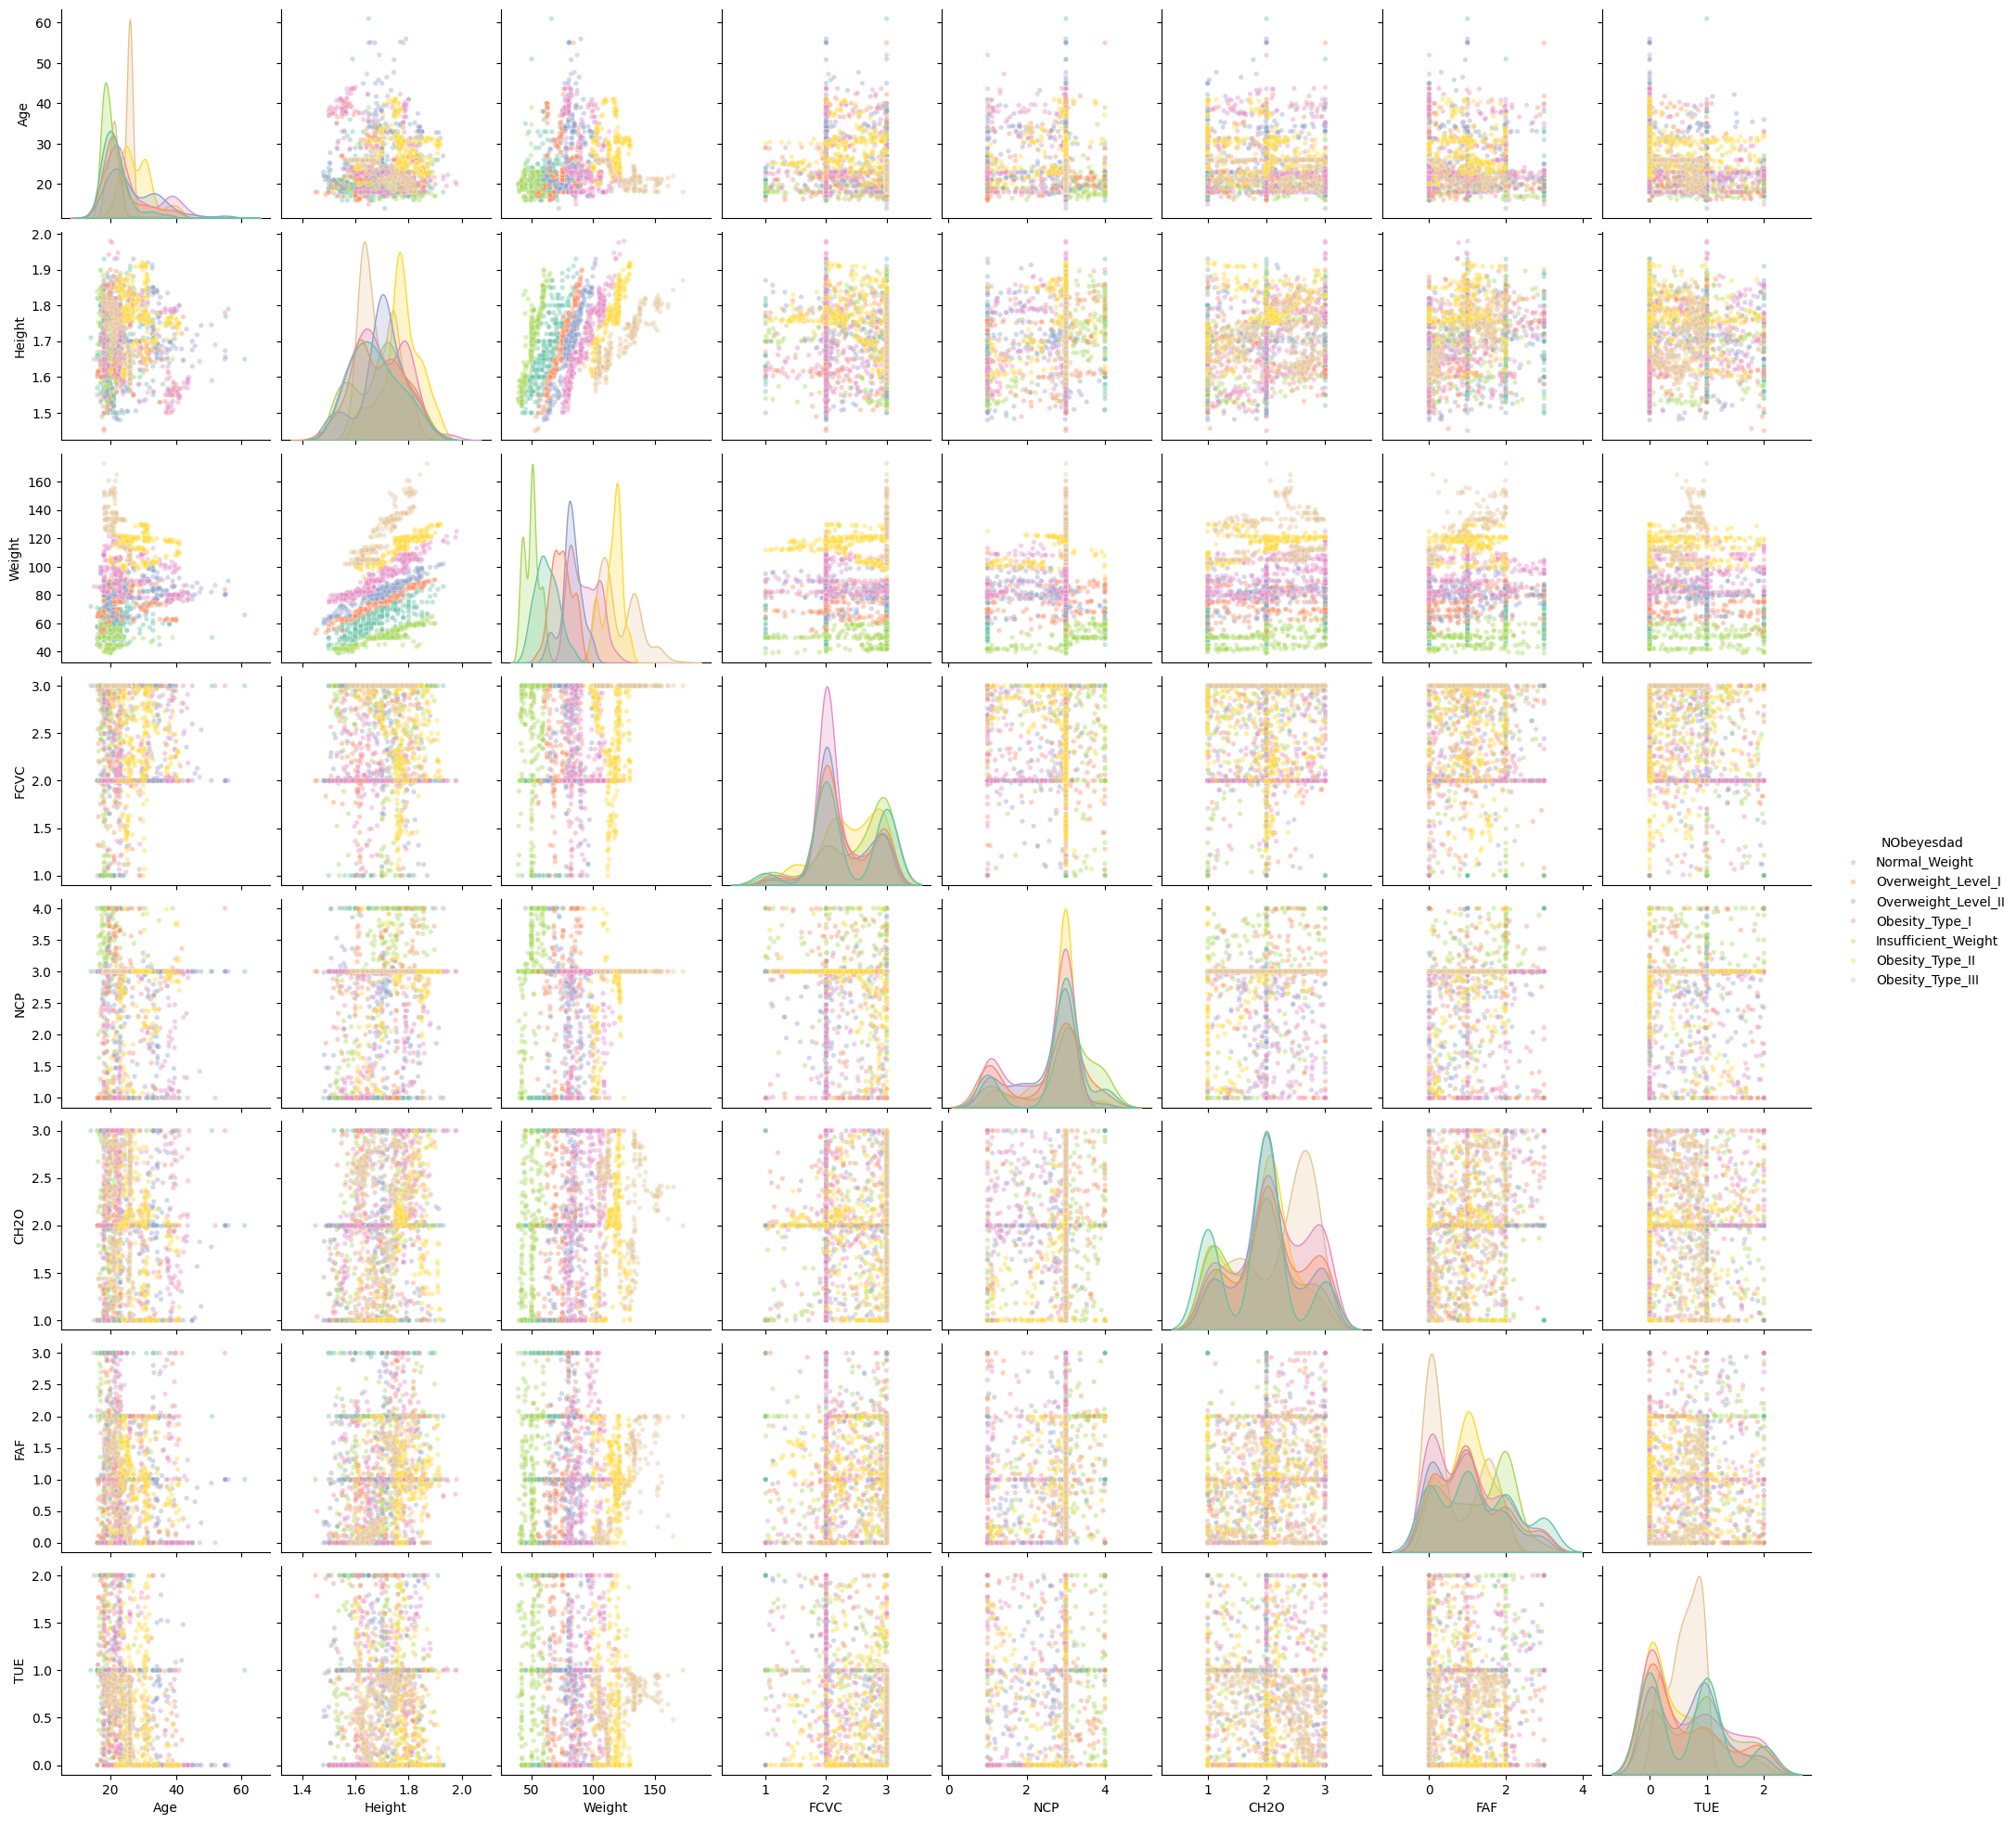

In [92]:
sns.pairplot(df[numeric_cols +  [target_col]],
             hue=target_col, palette='Set2', plot_kws={'alpha': 0.4, 's': 15})
plt.show()

## 3. Подготовка данных и осуществление Baseline модели

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics

In [131]:
X = df.drop(columns = target_col)
y = LabelEncoder().fit_transform(df[target_col])

numeric_cols = numeric_cols
categorical_cols = X.select_dtypes(exclude = np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

numeric_transformer = Pipeline(steps = [
    ("imp", SimpleImputer(strategy = "median")),
    ("stand_sc", StandardScaler())
])

categorical_transformer = Pipeline(steps = [
    ("imp", SimpleImputer(strategy = "most_frequent")),
    ("Ohe", OneHotEncoder(handle_unknown = "ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(solver='lbfgs',
    max_iter=1000,
    random_state=42))
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)


In [95]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        56
           1       0.91      0.63      0.74        62
           2       0.93      0.90      0.92        78
           3       0.90      0.97      0.93        58
           4       1.00      1.00      1.00        63
           5       0.75      0.75      0.75        56
           6       0.74      0.84      0.79        50

    accuracy                           0.87       423
   macro avg       0.87      0.87      0.86       423
weighted avg       0.87      0.87      0.87       423



In [96]:
y_proba = model_pipeline.predict_proba(X_test)

roc_auc = metrics.roc_auc_score(y_test, y_proba, multi_class='ovr')
print(roc_auc)

0.9881159297169712


## 4. Гипотезы

### 1) Дерево решений покажет больший accuracy на задаче, поскольку данные практически линейно неразделимы
### 2) При глубине дерева больше 15 модель DecisionTreeClassifier начнет переобучаться  
### 3) Если убрать признак weights, то качество DecisionTreeClassifier and LogisticRegression сильно упадет, примерно на 0.3-0.4 по метрике accuracy
### 4) При отборе признаков по важности (через DecisionTree), самыми важными будут Weight и Height 
### 5) При отборе признаков через RFECV, будут оставлены только 8-12 признаков при использовании DecisionTree 

## 5. Проверка первой гипотезы

In [97]:
from sklearn.tree import DecisionTreeClassifier, plot_tree


simple_tree = DecisionTreeClassifier(max_depth=30, random_state=42, criterion='gini')
tree_pipeline = Pipeline(steps = [
    ("prep", preprocessor),
    ("tree", simple_tree)
])
tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

In [98]:
print(metrics.classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        56
           1       0.87      0.89      0.88        62
           2       0.95      0.96      0.96        78
           3       0.96      0.95      0.96        58
           4       1.00      1.00      1.00        63
           5       0.91      0.89      0.90        56
           6       0.98      0.92      0.95        50

    accuracy                           0.94       423
   macro avg       0.94      0.94      0.94       423
weighted avg       0.94      0.94      0.94       423



## 6. Проверка второй гипотезы

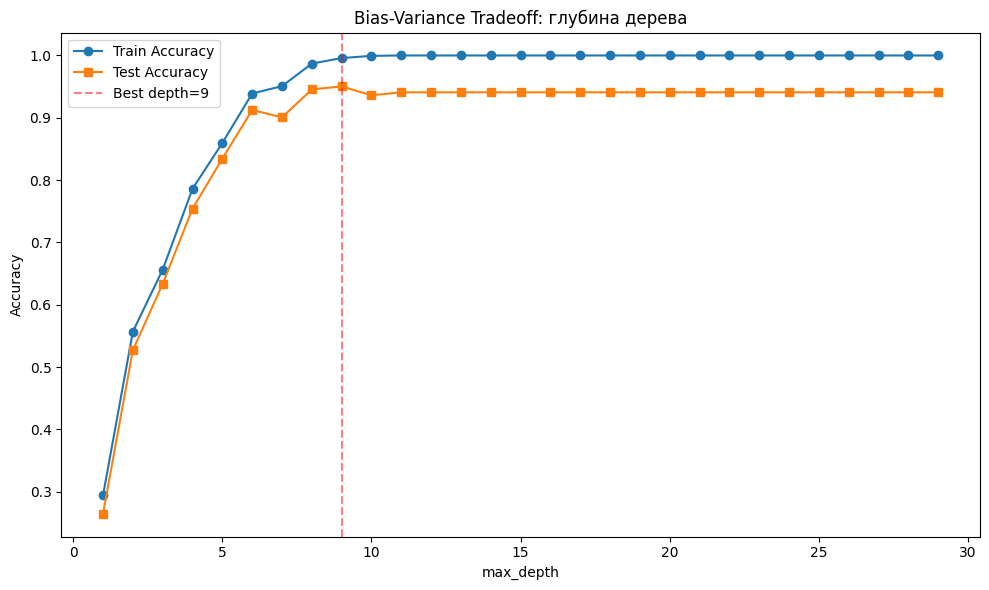

In [99]:
depths = range(1, 30)
train_acc, test_acc = [], []

for d in depths:
    dt = Pipeline(steps = [
        ("prep", preprocessor),
        ("tree", DecisionTreeClassifier(max_depth=d, random_state=42))])
    dt.fit(X_train, y_train)
    train_acc.append(metrics.accuracy_score(y_train, dt.predict(X_train)))
    test_acc.append(metrics.accuracy_score(y_test, dt.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_acc, 'o-', label='Train Accuracy')
ax.plot(depths, test_acc, 's-', label='Test Accuracy')
ax.axvline(x=depths[np.argmax(test_acc)], color='red', linestyle='--', alpha=0.5,
           label=f'Best depth={depths[np.argmax(test_acc)]}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Bias-Variance Tradeoff: глубина дерева')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Проверка третьей гипотезы

In [100]:
numeric_transformer_second = Pipeline(steps = [
    ("imp", SimpleImputer(strategy = "median")),
    ("stand_sc", StandardScaler())
])
categorical_transformer_second = Pipeline(steps = [
    ("imp", SimpleImputer(strategy = "most_frequent")),
    ("Ohe", OneHotEncoder(handle_unknown = "ignore"))
])

In [101]:
numeric_cols_check = [col for col in numeric_cols if col != "Weight"]
preprocessor_check = ColumnTransformer(transformers=[
    ("num", numeric_transformer_second, numeric_cols_check),
    ("cat", categorical_transformer_second, categorical_cols)
])

In [102]:
X_train_check = X_train.drop(columns = 'Weight')
X_test_check = X_test.drop(columns = 'Weight')
log_pipe = Pipeline(steps = [
    ("prep", preprocessor_check),
    ("log_model", LogisticRegression(solver = "lbfgs", max_iter = 1000, random_state = 42))
])
tree_pipe = Pipeline(steps =[
    ("prep", preprocessor_check),
    ("tree_model", DecisionTreeClassifier(max_depth=30, random_state=42, criterion='gini'))
])

log_pipe.fit(X_train_check, y_train)
tree_pipe.fit(X_train_check, y_train)
log_pred = log_pipe.predict(X_test_check)
tree_pred = tree_pipe.predict(X_test_check)

In [103]:
print("LogReg Metrics\n\n")
print(metrics.classification_report(y_test, log_pred))
print("\n")

LogReg Metrics


              precision    recall  f1-score   support

           0       0.59      0.79      0.67        56
           1       0.42      0.23      0.29        62
           2       0.59      0.62      0.60        78
           3       0.64      0.84      0.73        58
           4       0.97      1.00      0.98        63
           5       0.52      0.48      0.50        56
           6       0.41      0.32      0.36        50

    accuracy                           0.62       423
   macro avg       0.59      0.61      0.59       423
weighted avg       0.60      0.62      0.60       423





In [104]:
print("Tree Metrics\n\n")
print(metrics.classification_report(y_test, tree_pred))

Tree Metrics


              precision    recall  f1-score   support

           0       0.79      0.88      0.83        56
           1       0.65      0.53      0.58        62
           2       0.79      0.72      0.75        78
           3       0.87      0.91      0.89        58
           4       0.98      1.00      0.99        63
           5       0.61      0.62      0.62        56
           6       0.60      0.68      0.64        50

    accuracy                           0.76       423
   macro avg       0.76      0.76      0.76       423
weighted avg       0.76      0.76      0.76       423



## 8. Проверка четвертой гипотезы

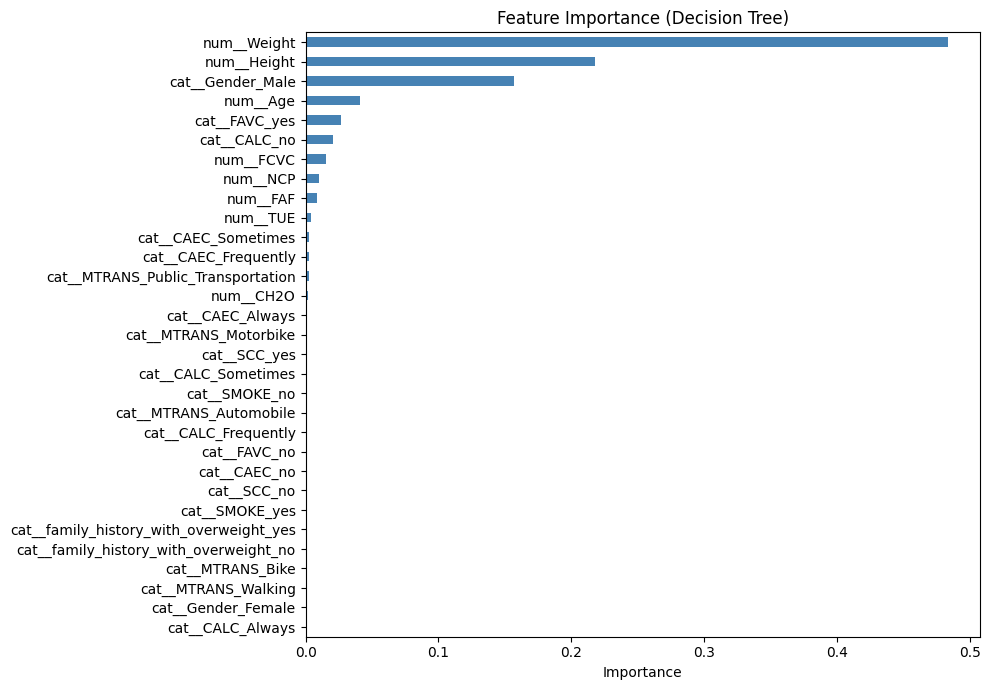

In [105]:
importances = pd.Series(tree_pipeline["tree"].feature_importances_, index= tree_pipeline.named_steps["prep"].get_feature_names_out()).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature Importance (Decision Tree)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Проверка пятой гипотезы

In [106]:
from sklearn.feature_selection import RFECV

pipe_RFE = Pipeline(steps = [
    ("prep", preprocessor),
    ("RFECV", RFECV(
        estimator=DecisionTreeClassifier(
            max_depth = 30,
            random_state = 42,
            criterion = "gini"
        ),
        step=1,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )),
    ("tree_model", DecisionTreeClassifier(
            max_depth = 30,
            random_state = 42,
            criterion = "gini"
        ))
])

In [107]:
pipe_RFE.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('stand_sc',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'CALC', 'FAVC',
                                                   'SCC', 'SMOKE',
                                                   'family_history_with_overweight',
                                                   'CAEC', 'MTRANS'])])),
                ('RFECV',
                 RFECV(cv=5,
                       estimator=DecisionTreeClassifier(max_depth=30,
                                                        random_state=42),
                       n_jobs=-1, scoring='f1_macro')),
                ('tree_model',
                 DecisionTreeClassifier(max_depth=30, random_state=42))])

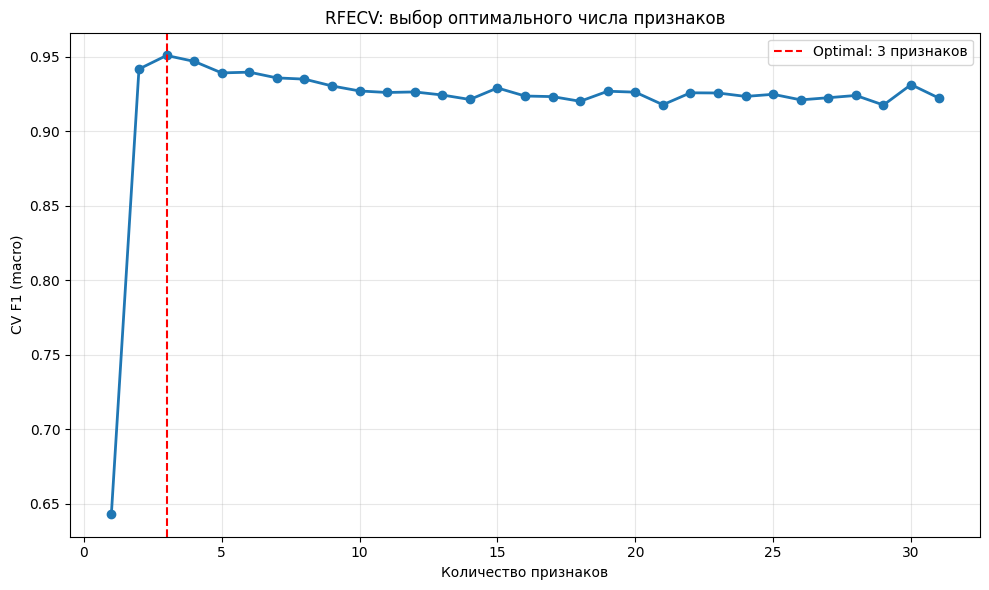

In [108]:
rfecv = pipe_RFE.named_steps['RFECV']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'],
    'o-', linewidth=2
)
ax.axvline(
    rfecv.n_features_,
    color='red',
    linestyle='--',
    label=f'Optimal: {rfecv.n_features_} признаков'
)
ax.set_xlabel('Количество признаков')
ax.set_ylabel('CV F1 (macro)')
ax.set_title('RFECV: выбор оптимального числа признаков')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [109]:
feature_names = pipe_RFE.named_steps['prep'].get_feature_names_out()
rfecv = pipe_RFE.named_steps['RFECV']

selected_features = feature_names[rfecv.support_]
print(selected_features)

['num__Height' 'num__Weight' 'cat__Gender_Male']


## 10. Подбор гиперпараметров и обучение лучшей модели

In [132]:
X_best_features = df[["Height", "Weight", "Gender"]]

In [133]:
X_best_features['Gender'] = (X['Gender'] == 'Male').astype(int)

/tmp/ipykernel_55/3906634914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_best_features['Gender'] = (X['Gender'] == 'Male').astype(int)


In [138]:
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(X_best_features, y, test_size = 0.2,
random_state = 42)

In [145]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 9, 10, 13, 15, 16, 17, 18, 20, None],
    'min_samples_split': [2, 5, 10, 20, 25, 30, 40],
    'min_samples_leaf': [1, 2, 5, 8, 10, 15],
    'criterion': ['gini', 'entropy'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1
)
grid_search.fit(X_train_best, y_train_best)

grid_search.best_params_, grid_search.best_score_.round(4)

({'criterion': 'entropy',
  'max_depth': 15,
  'min_samples_leaf': 1,
  'min_samples_split': 2},
 np.float64(0.9561))

In [150]:
from scipy.stats import randint, uniform

param_dist = {
    'max_depth': randint(2, 30),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf': randint(1, 30),
    'criterion': ['gini', 'entropy'],
}

rand_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dist, n_iter=100, cv=cv, scoring='f1_macro', random_state=42, n_jobs=-1
)
rand_search.fit(X_train_best, y_train_best)

rand_search.best_params_, rand_search.best_score_.round(4)

({'criterion': 'gini',
  'max_depth': 8,
  'min_samples_leaf': 1,
  'min_samples_split': 2},
 np.float64(0.9478))

In [154]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_best)

In [155]:
print("Best Model Results\n")
print(metrics.classification_report(y_test_best, y_pred))

Best Model Results

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        56
           1       0.92      0.89      0.90        62
           2       0.99      0.91      0.95        78
           3       0.92      1.00      0.96        58
           4       1.00      1.00      1.00        63
           5       0.93      0.91      0.92        56
           6       0.92      0.94      0.93        50

    accuracy                           0.94       423
   macro avg       0.94      0.94      0.94       423
weighted avg       0.94      0.94      0.94       423



## Итоговый вывод

В ходе работы была проведена разведочная аналитика данных, обучена baseline-модель `LogisticRegression`, а затем последовательно проверены гипотезы о поведении `DecisionTreeClassifier`, важности отдельных признаков и результатах отбора признаков. Эксперименты показали, что задача действительно имеет выраженную нелинейную структуру: baseline-модель на всех признаках дала `accuracy = 0.87`, тогда как дерево решений на тех же данных достигло `accuracy = 0.94`. Это говорит о том, что древовидная модель лучше улавливает зависимости в данных и лучше подходит для данной задачи классификации.

По итогам проверки гипотез можно сделать следующие выводы. Первая гипотеза подтвердилась: дерево решений действительно показало более высокое качество, чем логистическая регрессия, что согласуется с предположением о слабой линейной разделимости классов. Вторая гипотеза в целом тоже подтвердилась: по графику зависимости качества от `max_depth` видно, что после некоторой глубины модель начинает подгоняться под обучающую выборку сильнее, чем это полезно для тестовой, то есть появляются признаки переобучения; граница около `15` выглядит разумной и позже дополнительно поддерживается результатом `GridSearchCV`, где лучшая модель также выбрала `max_depth = 15`.

Третья гипотеза подтвердилась лишь частично. После удаления признака `Weight` качество действительно заметно ухудшилось, что подтверждает его высокую информативность. Однако падение оказалось не таким сильным, как предполагалось изначально: у логистической регрессии accuracy снизилась с `0.87` до `0.62`, а у дерева решений с `0.94` до `0.76`. То есть признак `Weight` критически важен, но модель всё же сохраняет часть предсказательной способности за счёт других признаков, прежде всего `Height` и `Gender`.

Четвертая гипотеза подтвердилась. Анализ важности признаков показал, что среди наиболее значимых действительно находятся `Weight` и `Height`. Более того, последующий отбор признаков через `RFECV` оставил именно их, а также признак `Gender`, что дополнительно подтверждает, что основная информация для классификации сосредоточена именно в антропометрических характеристиках.

Пятая гипотеза не подтвердилась. Ожидалось, что `RFECV` оставит примерно `8–12` признаков, однако на практике были выбраны только `3` признака: `Height`, `Weight` и `Gender`. Это означает, что многие остальные признаки либо избыточны, либо дают слишком небольшой вклад по сравнению с ключевыми физиологическими характеристиками. Иными словами, задача хорошо решается на очень компактном наборе признаков.

Финальный результат особенно важен тем, что после подбора гиперпараметров модель дерева решений, обученная только на `Height`, `Weight` и `Gender`, снова достигла `accuracy = 0.94`. Это показывает, что даже сильно сокращённое пространство признаков позволяет сохранить качество на уровне лучшей модели. Следовательно, итоговое исследование подтвердило, что для данной задачи решающими являются именно базовые антропометрические признаки, а использование дерева решений является оправданным и эффективным выбором.
